In [103]:
import pandas as pd
import numpy as np
from tqdm import tqdm

import matplotlib.pyplot as plt
import plotly.express as px

import utility_functions as uf

In [156]:
mode = "individual"

df_cs_yearly_full = pd.read_csv(uf.PATH+"df_cs_yearly.csv", index_col=[0, 1, 2]).xs(mode, level=2).fillna(0)
df_prob_yearly_full = df_cs_yearly_full.div(df_cs_yearly_full.sum(axis=1), axis=0)

In [158]:
n_years = 5

df_cs_roll_yearly_full = (
    df_cs_yearly_full
    .sort_index()
    .groupby(level=0)
    .rolling(n_years).sum()
    .reset_index(level=0, drop=True)
)
df_prob_roll_yearly_full = df_cs_roll_yearly_full.div(df_cs_roll_yearly_full.sum(axis=1), axis=0)

In [159]:
df_total_articles = (
    pd.DataFrame({}, index=df_cs_yearly_full.index)
    .assign(
        total = df_cs_yearly_full.sum(axis=1),
        total_roll = df_cs_roll_yearly_full.sum(axis=1)
    )
)

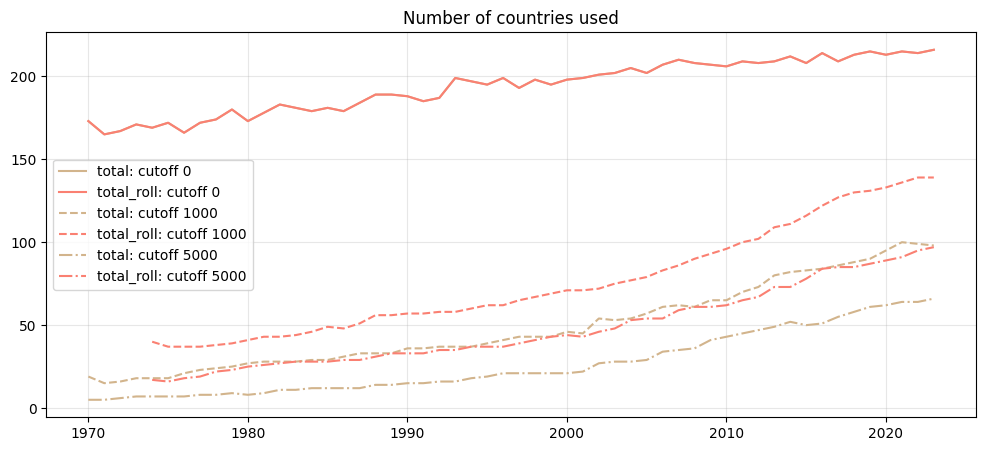

In [161]:
cap_articles_list = [0, 1000, 5000]
param_list = ["total", "total_roll"]

color_param = {
    "total": "tan", "total_roll": "salmon"
}
linestyle_cap = {
    0: "-", 1000: "--", 5000: "-."
}

plt.subplots(figsize=(12, 5))

for cap_articles_loop in cap_articles_list:
    for param in param_list:
        tmp = df_total_articles.query(param+" >= @cap_articles_loop").groupby(level=1)[param].count()
        plt.plot(tmp.index, tmp.values,
                 color = color_param[param], linestyle = linestyle_cap[cap_articles_loop],
                 label=f"{param}: cutoff {cap_articles_loop}")
plt.grid(alpha=0.3)
_ = plt.title("Number of countries used")
_ = plt.legend()

In [162]:
df_cutoff = (
    df_total_articles
    .assign(
        cutoff_5000 = lambda df: (df.total >= 5000).astype(int),
        cutoff_roll_5000 = lambda df: (df.total_roll >= 5000).astype(int),
        cutoff_1000 = lambda df: (df.total >= 1000).astype(int),
        cutoff_roll_1000 = lambda df: (df.total_roll >= 1000).astype(int)
    )
)

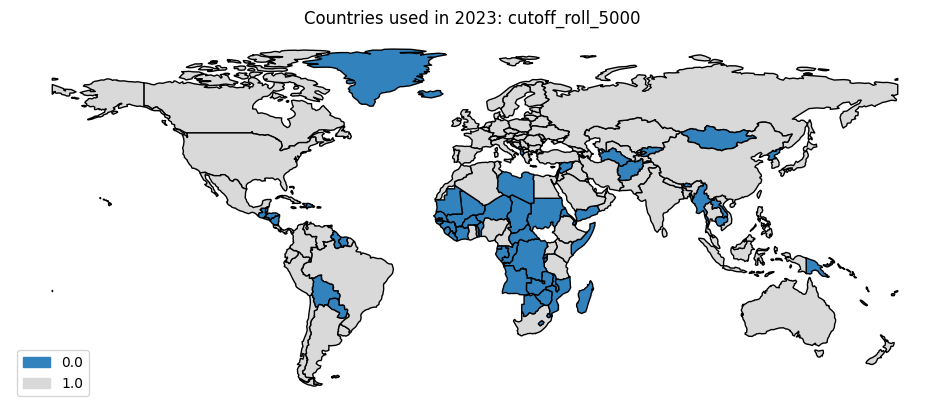

In [201]:
year = 2023
df_plot = df_cutoff.xs(year, level=1).merge(uf.df_country[["alpha-2", "alpha-3"]], left_index=True, right_on="alpha-2", how="left")

plot_column = "cutoff_roll_5000"
_ = uf.plot_map_discrete(df_plot, plot_column, title=f"Countries used in {year}: {plot_column}")

# Rolling and distances

## Distance between roling and usual

In [164]:
subfield_tree = uf.get_subfield_tree(uf.df_topics)

In [165]:
year = 2023
country = "RU"

df_dist_roll_non_roll = pd.DataFrame({}, index=df_prob_yearly_full.index)

for country, year in tqdm(df_dist_roll_non_roll.index):
    df_dist_roll_non_roll.loc[(country, year), "dist"] = uf.get_w1_distances(subfield_tree, (
        pd.concat([
            df_prob_yearly_full.loc[(country, year)],
            df_prob_roll_yearly_full.loc[(country, year)]
        ], axis=1)
        .T
        .reset_index(drop=True)
    )).iloc[0, 1]

100%|██████████| 10461/10461 [00:10<00:00, 990.08it/s]


In [235]:
country_list = ["US", "CN", "ID", "FR"]

cutoff = 1000

df_plot = (
    df_dist_roll_non_roll
    .merge(df_cutoff, left_index=True, right_index=True)
    .reset_index()
    .query("cutoff_roll_"+str(cutoff)+" == 1")
)

fig = px.box(df_plot, x="year", y="dist", hover_data="country", title=f"W1-tree distance between raw and rolling profiles (cutoff {cutoff})")


fig.update_traces(
    marker=dict(color="grey"),
    line=dict(color="grey"),
    opacity=0.5
)
for country in country_list:
    fig.add_scatter(
        x=df_dist_roll_non_roll.xs(country, level=0).index,
        y=df_dist_roll_non_roll.xs(country, level=0).dist,
        mode="lines",
        name=country,
        # line=dict(width=3)
    )
fig.show()

In [171]:
country = "PA"
year = 2023

df_profile_country = pd.concat([
            df_prob_yearly_full.loc[(country, year)],
            df_prob_roll_yearly_full.loc[(country, year)]
        ], axis=1).T.reset_index(drop=True).T.rename(columns={0: "Pure", 1: "Rolling"})
px.bar(df_profile_country, x=df_profile_country.index, y=["Pure", "Rolling"], barmode="overlay",
       title=f"Pure vs Rolling 5 years profiles: {uf.id2name_country[country]}, {year}")


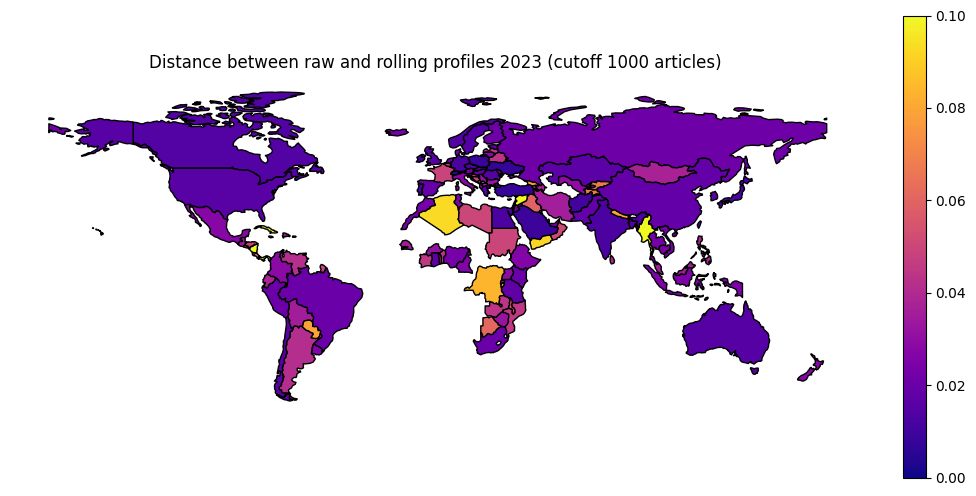

In [196]:
year = 2023
cutoff = 1000

df_plot = (
    df_dist_roll_non_roll.xs(year, level=1)
    .merge(df_cutoff.xs(year, level=1), left_index=True, right_index=True)
    .merge(uf.df_country[["alpha-2", "alpha-3"]], left_index=True, right_on="alpha-2")
    .query("cutoff_roll_"+str(cutoff)+" == 1")
)
_ = uf.plot_map_continuous(df_plot, "dist", range=(0, 0.1), title=f"Distance between raw and rolling profiles {year} (cutoff {cutoff} articles)")

## Compare country distances rolling 

In [202]:
subfield_tree = uf.get_subfield_tree(uf.df_topics)

In [233]:
year = 2015

df_dist = uf.get_w1_distances(subfield_tree, df_prob_yearly_full.xs(year, level=1))
df_dist_rolling = uf.get_w1_distances(subfield_tree, df_prob_roll_yearly_full.xs(year, level=1))

In [240]:
df = (
    df_dist.sub(df_dist_rolling)
)

cutoff = 1000
country_list_sorted = df_total_articles.xs(year, level=1).sort_values("total", ascending=False).query("total_roll >= @cutoff").index.to_list()

uf.plotly_heatmap(df.loc[country_list_sorted, country_list_sorted],
                  y_labels=country_list_sorted, x_labels=country_list_sorted,
                  z_min=-0.5, z_max=0.5, x_type="country", y_type="country",
                  title=f"(Distance raw - Distance rolling), {year}, cutoff = {cutoff}")

## Distance dynanics

In [288]:
start_year = 1970
end_year = 2023

df_dist_list = []
df_dist_rolling_list = []

for year_loop in tqdm(range(start_year, end_year+1)):
    df_dist = uf.get_w1_distances(subfield_tree, df_prob_yearly_full.xs(year_loop, level=1)).assign(year=year_loop).reset_index(names="country")
    np.fill_diagonal(df_dist.values, np.nan)
    df_dist_list.append(df_dist)
    if df_prob_roll_yearly_full.xs(year_loop, level=1).empty:
        continue
    df_dist_rolling = uf.get_w1_distances(subfield_tree, df_prob_roll_yearly_full.xs(year_loop, level=1)).assign(year=year_loop).reset_index(names="country")
    np.fill_diagonal(df_dist_rolling.values, np.nan)
    df_dist_rolling_list.append(df_dist_rolling)

df_dist_yearly = pd.concat(df_dist_list).set_index(["country", "year"])
df_dist_rolling_yearly = pd.concat(df_dist_rolling_list).set_index(["country", "year"])

100%|██████████| 54/54 [10:56<00:00, 12.16s/it]


In [289]:
df_dist_rolling_yearly.to_csv(uf.PATH+"df_dist_w1_rolling_yearly_individual.csv")
df_dist_yearly.to_csv(uf.PATH+"df_dist_w1_yearly_individual.csv")

In [290]:
df_plot = pd.concat([df_dist_rolling_yearly.mean(axis=1).to_frame("mean_dist").assign(mode="rolling"),
           df_dist_yearly.mean(axis=1).to_frame("mean_dist").assign(mode="raw")], axis=0).reset_index()
px.box(df_plot, x="year", y="mean_dist", color="mode", title="Mean distance distributions")

In [291]:
country_list = ["US", "CN", "ID", "FR", "RU", "AU", "BR"]

cutoff = 5000

df_plot = pd.concat([df_dist_rolling_yearly.median(axis=1).to_frame("mean_dist").assign(mode="rolling"),
           df_dist_yearly.median(axis=1).to_frame("mean_dist").assign(mode="raw")], axis=0).merge(df_cutoff, left_index=True, right_index=True).reset_index()

fig = px.box(
    df_plot.query("cutoff_roll_"+str(cutoff)+" == 1"),
    x="year",
    y="mean_dist",
    color="mode",
    title=f"Mean country-distance distributions, cutoff = {cutoff}",
    hover_data=["country"],
    color_discrete_map={
        "rolling": "grey",
        "raw": "darkgrey"
    }
)
mode_rolling = "rolling"
for country in country_list:
    fig.add_scatter(
        x=df_plot.query("country == @country and mode == @mode_rolling and mean_dist > 0").year,
        y=df_plot.query("country == @country and mode == @mode_rolling and mean_dist > 0").mean_dist,
        mode="lines",
        name=country,
        # line=dict(width=3)
    )
fig.show()